In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session




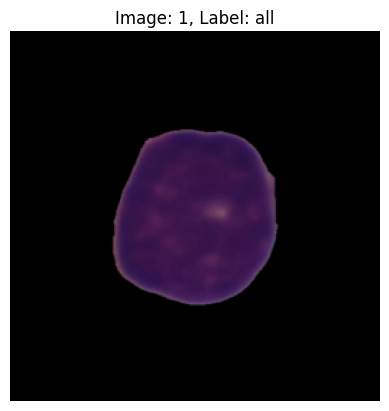

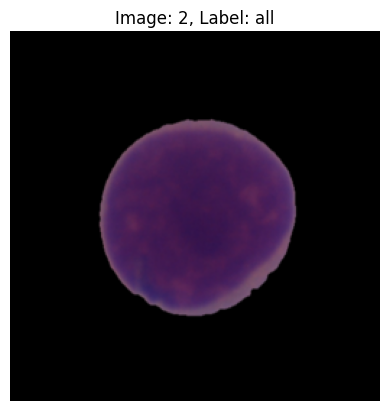

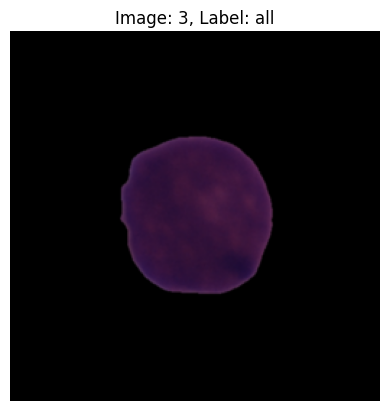

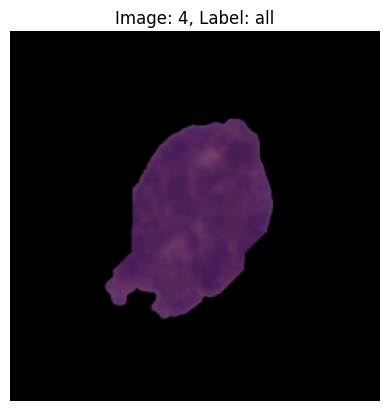

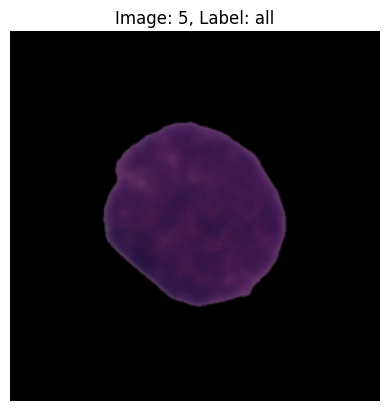

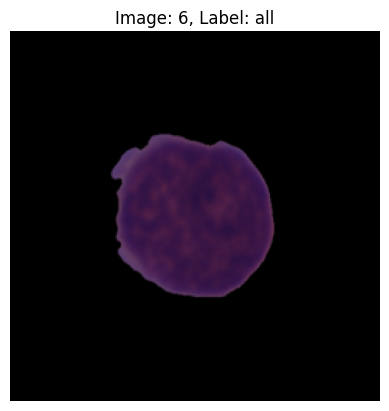

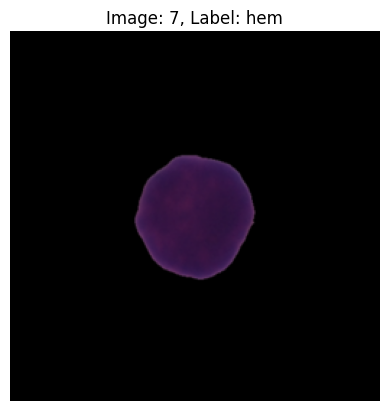

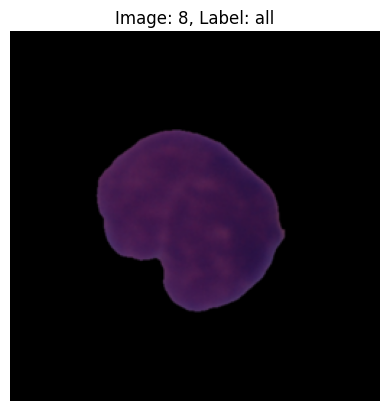

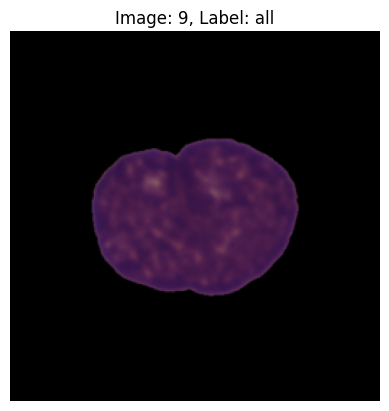

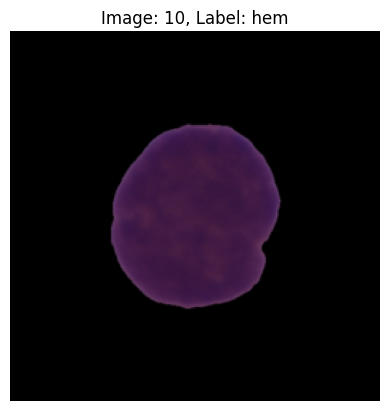

In [1]:
import torch
from torch.utils.data import DataLoader, random_split, ConcatDataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

data_dir_0 = '/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_0'
data_dir_1 = '/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_1'
data_dir_2 = '/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_2'
 

dataset_0 = datasets.ImageFolder(root=data_dir_0)
dataset_1 = datasets.ImageFolder(root=data_dir_1)
dataset_2 = datasets.ImageFolder(root=data_dir_2)
# test_dataset = datasets.ImageFolder(root=data_dir_all, transform=test_transforms)



# TODO: use diff transformers for diff classes e,g all  vs hem
# Y - class A - transformer 1 , Y - class B  transformer 2

# TODO: use diff transform 
# test resize + tenzor

# Combine all folds into a single dataset
full_dataset = ConcatDataset([dataset_0, dataset_1, dataset_2])


# Split into train and test datasets (80-20 split)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

# DataLoaders for batching
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

train_transform = transforms.Compose([
    transforms.Resize((256, 256)), 
    # transforms.RandomHorizontalFlip(p=0.5), 
    transforms.ToTensor(), 
])

test_transform = transforms.Compose([
    transforms.Resize((256, 256)),  
    transforms.ToTensor(),  
])


# Custom Dataset class with transform
class TransformDataset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
        
    def __len__(self):
        return len(self.subset)

# Apply transforms to training and test data
train_data = TransformDataset(train_dataset, transform=train_transform)
test_data = TransformDataset(test_dataset, transform=test_transform)

# DataLoaders for batching
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)


# Visualize some images
for i in range(10):  # Show 3 images
    img, label = train_data[i]

    # Convert tensor to a NumPy array for plotting
    img = img.numpy().transpose((1, 2, 0))  # Convert (C, H, W) to (H, W, C)

    # Get the label name from the dataset class labels
    label_name = dataset_0.classes[label]  # Use dataset_0 since classes should be the same across folds

    # Plot the image with a title (including label name)
    plt.imshow(img)
    plt.title(f"Image: {i+1}, Label: {label_name}")
    plt.axis('off')
    plt.show()
    
    
   